In [2]:
# Path

import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

In [3]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt

from pangya_physics import Ball, CLUBS, PangyaSimulator, Vector3D, Wind

In [4]:
# Função de Simulação

def simulate_shot(
    label,
    wind_speed=0,
    wind_degree=0,
    rotation_spin=0,
    rotation_curve=0,
    velocity_y=40,
    velocity_z=220,
    steps=300,
):
    ball = Ball(
        velocity=Vector3D(0.0, velocity_y, velocity_z),
        rotation_spin=rotation_spin,
        rotation_curve=rotation_curve,
    )

    club = CLUBS["1W"]
    wind = Wind(speed=wind_speed, degree=wind_degree)

    simulator = PangyaSimulator(ball=ball, club=club, wind=wind)

    trajectory = []

    for _ in range(steps):
        simulator.step()

        trajectory.append(
            {
                "label": label,
                "step": simulator.ball.count,
                "x": simulator.ball.position.x,
                "y": simulator.ball.position.y,
                "z": simulator.ball.position.z,
                "velocity_x": simulator.ball.velocity.x,
                "velocity_y": simulator.ball.velocity.y,
                "velocity_z": simulator.ball.velocity.z,
            }
        )

    return pd.DataFrame(trajectory)

In [5]:
# Cenários

scenarios = [
    simulate_shot("Sem vento"),
    simulate_shot("Vento frontal", wind_speed=9, wind_degree=180),
    simulate_shot("Vento a favor", wind_speed=9, wind_degree=0),
    simulate_shot("Vento lateral", wind_speed=9, wind_degree=90),
    simulate_shot("Com spin", rotation_spin=0.5),
    simulate_shot("Com curva", rotation_curve=0.5),
]

df = pd.concat(scenarios, ignore_index=True)

df.head()

,label,step,x,y,z,velocity_x,velocity_y,velocity_z
0,Sem vento,1,0.0,0.780050,4.365724,0.0,39.002494,218.286202
1,Sem vento,2,0.0,1.540356,8.697723,0.0,38.015292,216.599926
2,Sem vento,3,0.0,2.281119,12.996533,0.0,37.038142,214.940506
3,Sem vento,4,0.0,3.002535,17.262679,0.0,36.070804,213.307294
4,Sem vento,5,0.0,3.704796,21.496672,0.0,35.113044,211.699666


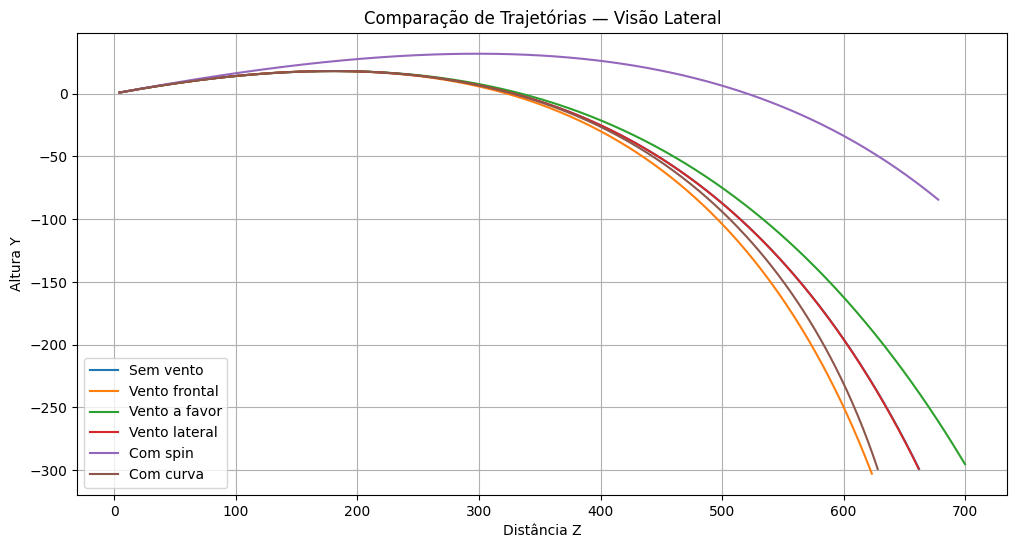

In [6]:
# Trajetória lateral

plt.figure(figsize=(12, 6))

for label in df["label"].unique():
    sample = df[df["label"] == label]
    plt.plot(sample["z"], sample["y"], label=label)

plt.title("Comparação de Trajetórias — Visão Lateral")
plt.xlabel("Distância Z")
plt.ylabel("Altura Y")
plt.legend()
plt.grid(True)
plt.show()

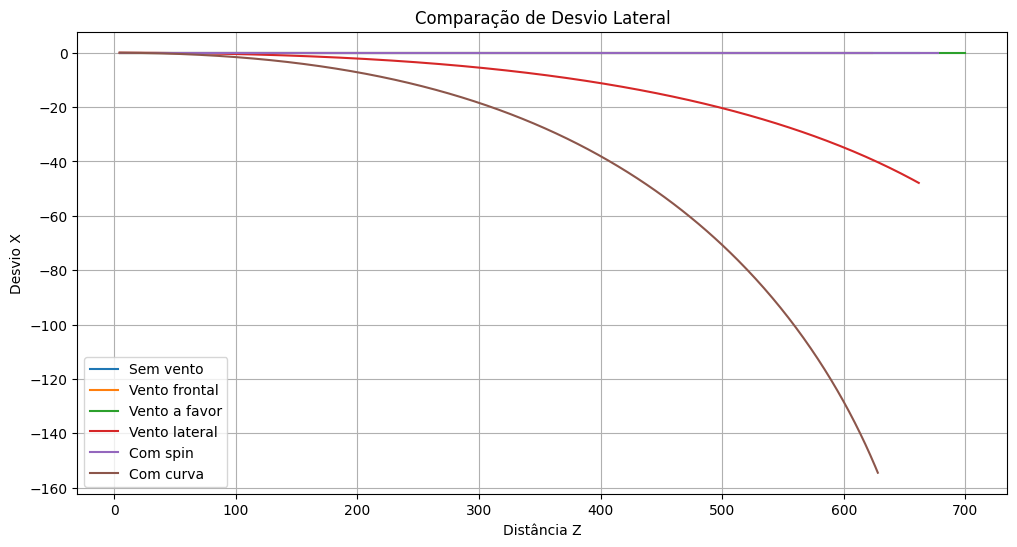

In [7]:
# Desvio lateral

plt.figure(figsize=(12, 6))

for label in df["label"].unique():
    sample = df[df["label"] == label]
    plt.plot(sample["z"], sample["x"], label=label)

plt.title("Comparação de Desvio Lateral")
plt.xlabel("Distância Z")
plt.ylabel("Desvio X")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Resumo final

summary = (
    df.groupby("label")
    .agg(
        max_height=("y", "max"),
        final_distance=("z", "max"),
        final_side_deviation=("x", "last"),
    )
    .reset_index()
)

summary

,label,max_height,final_distance,final_side_deviation
0,Com curva,17.914244,628.021083,-1.544821e+02
1,Com spin,31.704730,677.824894,0.000000e+00
2,Sem vento,17.914278,662.060655,0.000000e+00
3,Vento a favor,17.899040,699.841563,0.000000e+00
4,Vento frontal,17.929549,623.209758,-5.946243e-15
5,Vento lateral,17.914220,661.703167,-4.788579e+01
